In [1]:
import pandas as pd
import re
from sentence_transformers import SentenceTransformer
import umap
import hdbscan

C:\Users\HP\PycharmProjects\ml model\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("almaty_psc_hospital_wrangled.csv")

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-zA-Zа-яА-ЯёЁіІңҢәӘөӨұҰқҚғҒүҮұҰ\n]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['text_clean'] = df['review_text'].apply(clean_text)

df[['review_text', 'text_clean']].head()

,review_text,text_clean
0,бардак номер қателесіп беріп жіберген өзің бар...,бардак номер қателесіп беріп жіберген өзің бар...
1,здраствуйте хочу рассказать о случае в котором...,здраствуйте хочу рассказать о случае в котором...
2,нервные сотрудники часов ожиданий в пустую не...,нервные сотрудники часов ожиданий в пустую не ...
3,здрово,здрово
4,барлығы өз ісінің маманы,барлығы өз ісінің маманы


In [3]:
import warnings
warnings.filterwarnings('ignore')
model = SentenceTransformer('sentence-transformers/distiluse-base-multilingual-cased-v2')

texts = df['text_clean'].tolist()
embeddings = model.encode(texts, show_progress_bar=True)
embeddings.shape

Batches: 100%|██████████| 734/734 [17:39<00:00,  1.44s/it]


(23465, 512)

In [33]:
umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=10,
    min_dist=0.0,
    metric='cosine',
    random_state=77
)

X_umap_10 = umap_model.fit_transform(embeddings)
X_umap_10.shape

(23465, 10)

In [34]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    metric='euclidean',
    cluster_selection_method='eom'
)

labels = clusterer.fit_predict(X_umap_10)
df['cluster'] = labels
df['cluster'].value_counts(dropna=False)

cluster
 0    15775
 2     7407
 1      261
-1       22
Name: count, dtype: int64

Average Silhouette Score: 0.45443735


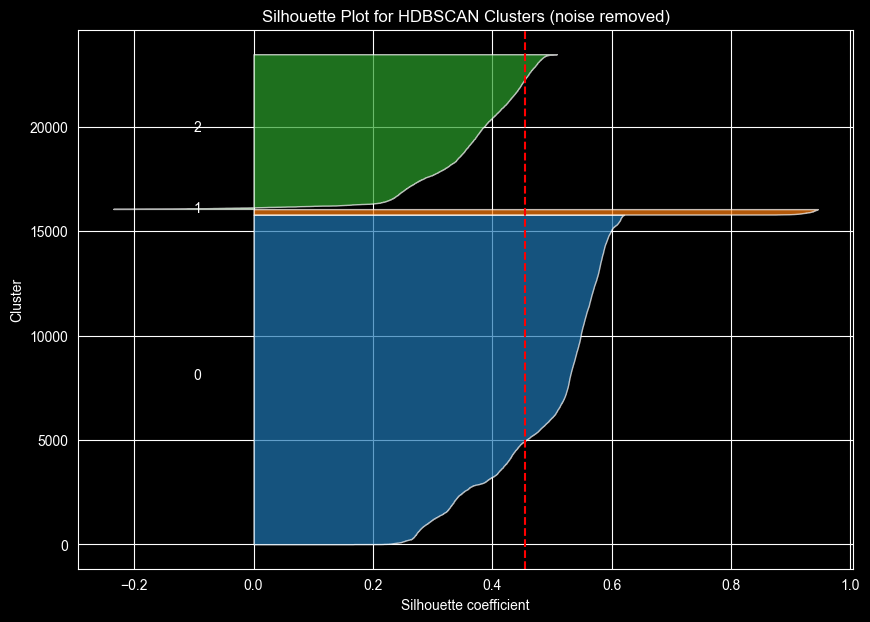

In [35]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np

mask = df['cluster'] != -1
X_for_sil = X_umap_10[mask]
labels_for_sil = df['cluster'][mask]

sil_avg = silhouette_score(X_for_sil, labels_for_sil)
print("Average Silhouette Score:", sil_avg)

sil_values = silhouette_samples(X_for_sil, labels_for_sil)

clusters = sorted(df['cluster'][mask].unique())

plt.figure(figsize=(10, 7))

y_lower = 10
for cid in clusters:
    cid_sil = sil_values[labels_for_sil == cid]
    cid_sil.sort()

    size = cid_sil.shape[0]
    y_upper = y_lower + size

    color = plt.cm.tab10(cid % 10)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cid_sil, facecolor=color, alpha=0.7)

    plt.text(-0.1, y_lower + size / 2, str(cid))
    y_lower = y_upper + 10

plt.axvline(x=sil_avg, color="red", linestyle="--")
plt.title("Silhouette Plot for HDBSCAN Clusters (noise removed)")
plt.xlabel("Silhouette coefficient")
plt.ylabel("Cluster")
plt.show()

In [36]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
import numpy as np

def extract_top_terms(df, cluster_col='cluster', n_terms=15):
    groups = df[df[cluster_col] != -1].groupby(cluster_col)['text_clean'].apply(lambda x: " ".join(x))

    vectorizer = CountVectorizer(ngram_range=(1, 2), min_df=3)
    counts = vectorizer.fit_transform(groups)

    transformer = TfidfTransformer()
    tfidf = transformer.fit_transform(counts)

    terms = np.array(vectorizer.get_feature_names_out())

    for i, row in enumerate(tfidf.toarray()):
        top = row.argsort()[::-1][:n_terms]
        print(f"\n### CLUSTER {groups.index[i]} ###")
        print(", ".join(terms[top]))

extract_top_terms(df, 'cluster', n_terms=20)


### CLUSTER 0 ###
не, на, что, все, за, по, как, очень, быстро, это, работает, так, то, но, очередь, очереди, до, сотрудники, нет, просто

### CLUSTER 1 ###
не, на, что, все, зуб, за, очень, мудрости, меня, как, но, зуба, врач, мне, было, быстро, это, по, спасибо, он

### CLUSTER 2 ###
не, на, что, за, очень, все, спасибо, как, по, благодарность, врач, это, хочу, врачи, так, вам, но, меня, от, мне


In [37]:
for cid in sorted(df['cluster'].unique()):
    print("\n" + "="*60)
    print(f"CLUSTER {cid} (count of comments: {len(df[df['cluster']==cid])})")
    print("="*60)
    sample = df[df['cluster'] == cid].sample(min(7, len(df[df['cluster'] == cid])), random_state=77)
    for t in sample['review_text']:
        print("-", t)
        print()


CLUSTER -1 (count of comments: 22)
- No Review

- No Review

- без комментариев ужас

- No Review

- No Review

- No Review

- No Review


CLUSTER 0 (count of comments: 15775)
- ненавижу это место сотрудники дикари конкретные никакой организованности

- сегодня у них база не работала подождали и в итоге так и не заработала попросили в другой цон съездить мне надо было сдать больничный лист декретный

- меня обслужили очень быстро девочки но на регистрации котороые сидят двое не довольные и уставшие 
надеюсь в срок получить документы

- благодарю девушку на м столе по выдаче паспорта подождала меня хотя я опаздывала на  минут и приехала в  паспорт все равно получила спасибо имя не помню сегодня  девушка на м столе по выдаче паспортов спасибо за понимаете 

- баглан грубиянка начальница какая то вроде она не знающая свою работу хамло не хочет работать поехал в другой цен всё сделали без вопросов пока работают такие люди такое же мнение и останется у людей

- был г база не работала но ла

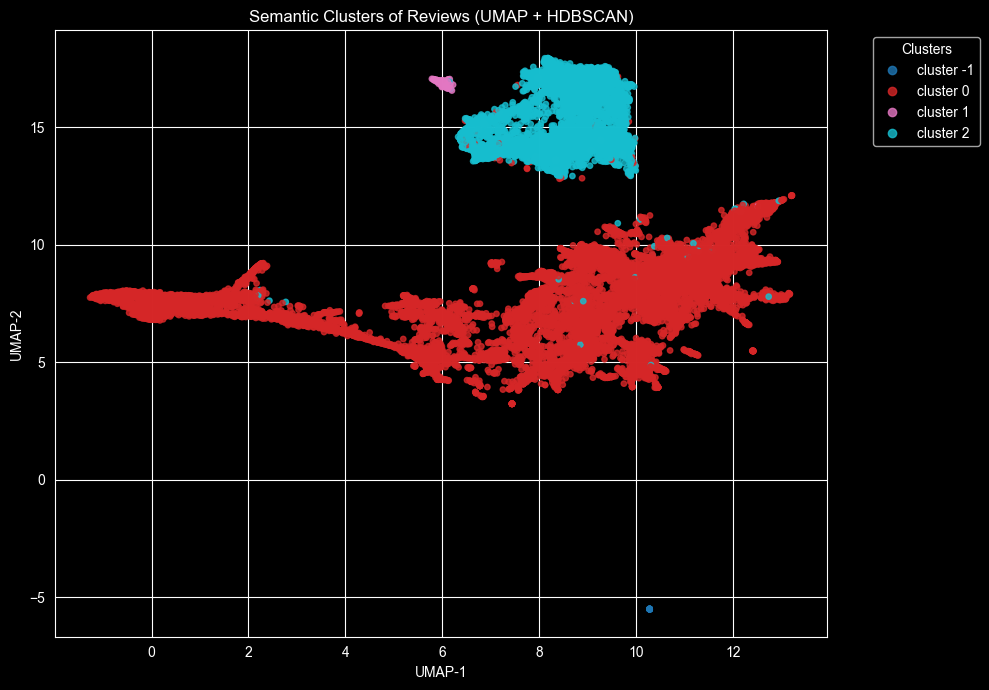

In [38]:
umap_2 = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

X_umap_2 = umap_2.fit_transform(embeddings)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_umap_2[:, 0],
    X_umap_2[:, 1],
    c=df['cluster'],
    cmap='tab10',
    s=15,
    alpha=0.8
)

plt.title("Semantic Clusters of Reviews (UMAP + HDBSCAN)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

handles = scatter.legend_elements()[0]
labels = [f"cluster {c}" for c in sorted(df['cluster'].unique())]
plt.legend(handles, labels, title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()